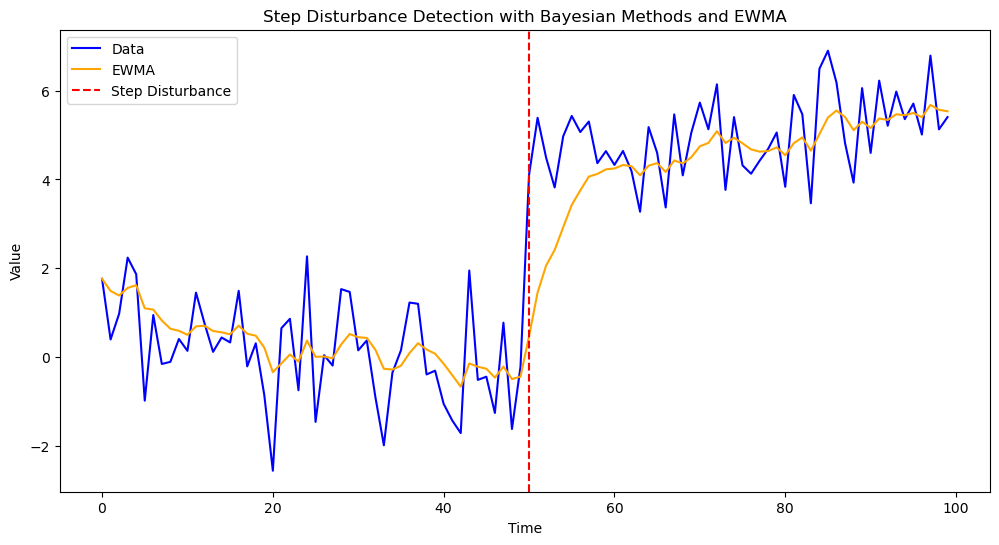

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from filterpy.discrete_bayes import normalize, update, predict

# Generate synthetic data with step disturbance
np.random.seed(0)
n = 100
data = np.random.normal(loc=0, scale=1, size=n)
data[50:] += 5  # Step disturbance

# Define parameters for Bayesian update
prior = np.ones(n) / n  # Uniform prior
likelihood = np.zeros(n)
posterior_values = np.zeros((n, n))  # Store posterior values

# Define EWMA parameters
alpha = 0.2
ewma = np.zeros(n)
ewma[0] = data[0]

# Define a kernel for the prediction
kernel = np.ones(3) / 3  # Simple moving average kernel

# Bayesian update loop
for t in range(n):
    # Calculate likelihood (e.g., Gaussian)
    likelihood[t] = np.exp(-0.5 * ((data[t] - np.mean(data)) / 1) ** 2)
    
    # Normalize the likelihood
    likelihood = normalize(likelihood)
    
    # Bayesian update
    posterior = update(likelihood, prior)
    posterior_values[t, :] = posterior  # Store the posterior
    
    # Predict next step
    prior = predict(posterior, offset=1, kernel=kernel, mode='wrap', cval=0.0)
    
    # Update EWMA
    ewma[t] = alpha * data[t] + (1 - alpha) * ewma[t - 1] if t > 0 else data[t]

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(data, label='Data', color='blue')
plt.plot(ewma, label='EWMA', color='orange')
plt.axvline(x=50, color='red', linestyle='--', label='Step Disturbance')
plt.title('Step Disturbance Detection with Bayesian Methods and EWMA')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

# Plot the change of posterior
plt.figure(figsize=(12, 6))
for t in range(0, n, 10):  # Plot every 10th posterior
    plt.plot(posterior_values[t, :], label=f'Time {t}')
plt.title('Change of Posterior Probability Distribution Over Time')
plt.xlabel('State Index')
plt.ylabel('Posterior Probability')
plt.legend()
plt.show()
